
# Regularization: Linear Regression vs Ridge (L2) vs Lasso (L1) vs ElasticNet

## Learning Objectives
- Understand overfitting and the bias-variance tradeoff
- Train a baseline Linear Regression model
- Apply Ridge (L2), Lasso (L1), and ElasticNet
- Compare coefficients, train performance, and test performance
- Observe how regularization shrinks coefficients
- Understand feature selection in Lasso


In [ ]:

import numpy as np
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)



## Step 1: Create a Dataset

We intentionally create:
- Many features
- Noise
- A few informative features

This setup helps us observe the effect of regularization.


In [2]:

X, y = make_regression(
    n_samples=300,
    n_features=20,
    n_informative=5,
    noise=30,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (240, 20)
Testing samples: (60, 20)



## Step 2: Baseline Linear Regression

No regularization is applied.

Objective:

Loss = RSS

The model only tries to minimize prediction error.


In [3]:

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

print("Linear Regression")
print("Train R²:", round(r2_score(y_train, pred_train),4))
print("Test R² :", round(r2_score(y_test, pred_test),4))
print("Train MSE:", round(mean_squared_error(y_train, pred_train),2))
print("Test MSE :", round(mean_squared_error(y_test, pred_test),2))


Linear Regression
Train R²: 0.9325
Test R² : 0.8885
Train MSE: 835.11
Test MSE : 1265.11



## Step 3: Ridge Regression (L2)

Ridge Objective:

Loss = RSS + λΣ(w²)

### Key Observations
- Shrinks coefficients
- Does NOT make coefficients exactly zero
- Useful when features are correlated


In [4]:

ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Test R² :", round(r2_score(y_test, ridge_pred),4))
print("Ridge Test MSE:", round(mean_squared_error(y_test, ridge_pred),2))


Ridge Test R² : 0.8857
Ridge Test MSE: 1297.15



## Step 4: Lasso Regression (L1)

Lasso Objective:

Loss = RSS + λΣ|w|

### Key Observations
- Shrinks coefficients
- Can make coefficients exactly zero
- Performs automatic feature selection


In [5]:

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso Test R² :", round(r2_score(y_test, lasso_pred),4))
print("Lasso Test MSE:", round(mean_squared_error(y_test, lasso_pred),2))

print("\nNumber of coefficients exactly zero:")
print(np.sum(lasso.coef_ == 0))


Lasso Test R² : 0.8864
Lasso Test MSE: 1289.05

Number of coefficients exactly zero:
5



## Step 5: ElasticNet

ElasticNet combines Ridge and Lasso.

Loss = RSS + λ(ρΣ|w| + (1-ρ)Σw²)

### Key Observations
- Shrinks coefficients
- Can remove some features
- Handles correlated features better than pure Lasso


In [6]:

elastic = ElasticNet(alpha=1.0, l1_ratio=0.6)
elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_test)

print("ElasticNet Test R² :", round(r2_score(y_test, elastic_pred),4))
print("ElasticNet Test MSE:", round(mean_squared_error(y_test, elastic_pred),2))


ElasticNet Test R² : 0.8044
ElasticNet Test MSE: 2219.29



## Step 6: Compare Coefficients

Regularization primarily affects coefficients.

Observe:
- Linear Regression keeps larger coefficients
- Ridge shrinks them
- Lasso may set some to zero
- ElasticNet provides a balance


In [7]:

coef_df = pd.DataFrame({
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

coef_df.head(5)


,Linear,Ridge,Lasso,ElasticNet
0,1.372788,1.608490,0.349640,2.090607
1,0.824315,0.823417,0.000000,0.332882
2,-2.749581,-2.602283,-1.518410,-1.536132
3,1.571922,1.824375,0.967102,2.586204
4,2.356024,1.930036,1.251040,-0.000000


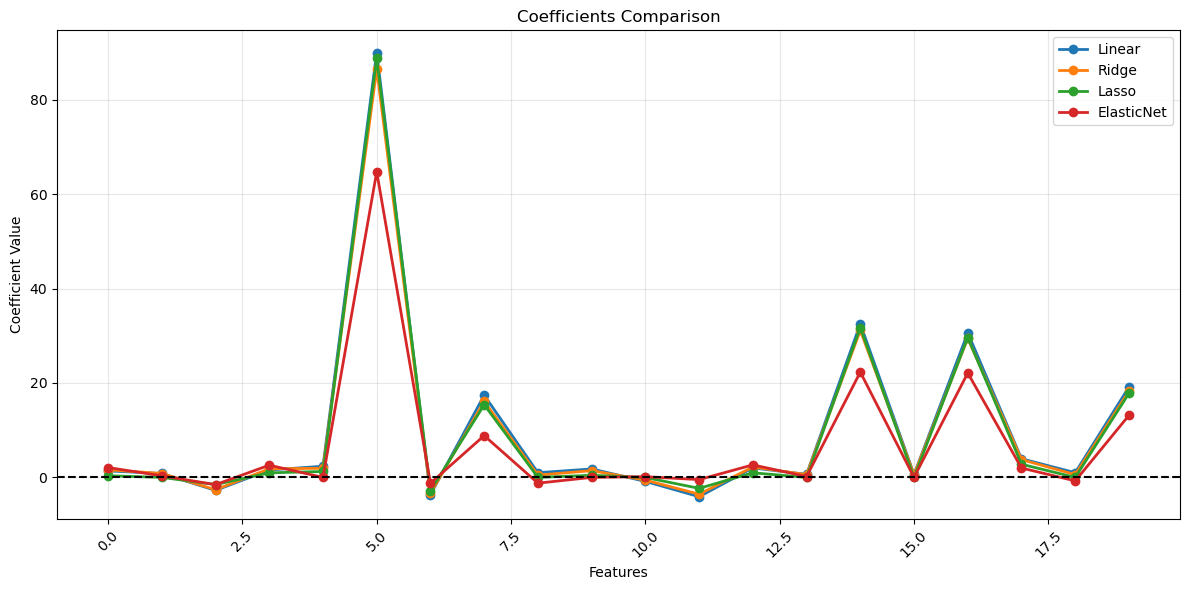

In [22]:
plt.figure(figsize=(12,6))

for model in coef_df.columns:
    plt.plot(
        coef_df.index,
        coef_df[model],
        marker='o',
        linewidth=2,
        label=model
    )

plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.title("Coefficients Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Step 7: Performance Comparison Table


In [12]:

results = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso","ElasticNet"],
    "R2":[
        r2_score(y_test, lr.predict(X_test)),
        r2_score(y_test, ridge.predict(X_test)),
        r2_score(y_test, lasso.predict(X_test)),
        r2_score(y_test, elastic.predict(X_test))
    ],
    "MSE":[
        mean_squared_error(y_test, lr.predict(X_test)),
        mean_squared_error(y_test, ridge.predict(X_test)),
        mean_squared_error(y_test, lasso.predict(X_test)),
        mean_squared_error(y_test, elastic.predict(X_test))
    ]
})

results.sort_values("R2", ascending=False)


,Model,R2,MSE
0,Linear Regression,0.888481,1265.109309
2,Lasso,0.886370,1289.054757
1,Ridge,0.885657,1297.148258
3,ElasticNet,0.804371,2219.288218


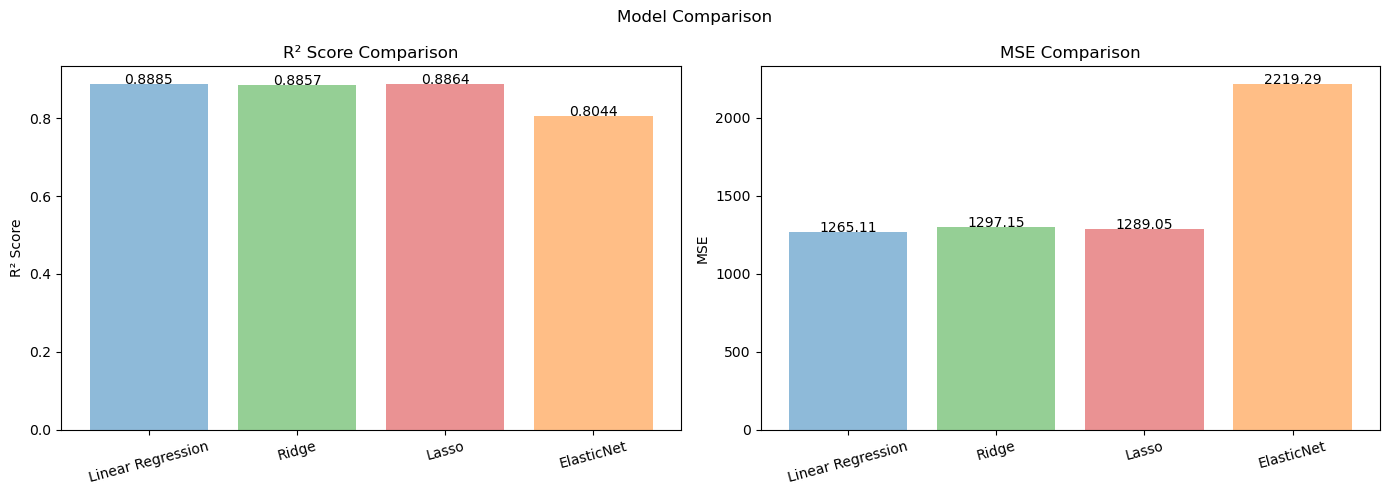

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

colors = [
    '#1f77b4',  # Linear - Blue
    '#2ca02c',  # Ridge - Green
    '#d62728',  # Lasso - Red
    '#ff7f0e'   # ElasticNet - Orange
]

# R2
axes[0].bar(results["Model"], results["R2"], color=colors, alpha=0.5)
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")
axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(results["R2"]):
    axes[0].text(i, v, f"{v:.4f}", ha='center')

# MSE
axes[1].bar(results["Model"], results["MSE"], color=colors, alpha=0.5)
axes[1].set_title("MSE Comparison")
axes[1].set_ylabel("MSE")
axes[1].tick_params(axis='x', rotation=15)

for i, v in enumerate(results["MSE"]):
    axes[1].text(i, v, f"{v:.2f}", ha='center')

plt.suptitle('Model Comparison')
plt.tight_layout()
plt.show()


# Theory Recap

## Linear Regression
Loss = RSS

- No penalty
- Higher chance of overfitting

---

## Ridge (L2)
Loss = RSS + λΣ(w²)

- Shrinks coefficients
- Rarely reaches zero
- Good for multicollinearity

---

## Lasso (L1)
Loss = RSS + λΣ|w|

- Shrinks coefficients
- Can make coefficients exactly zero
- Feature selection

---

## ElasticNet
Loss = RSS + λ(ρΣ|w| + (1-ρ)Σw²)

- Combination of L1 and L2
- Feature selection + coefficient shrinkage
- Often a strong practical choice

---

